<a href="https://colab.research.google.com/github/DevGaonkar/project-0/blob/main/AIDS_2_Exp_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset and split into training and testing sets
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# Normalize the pixel values from 0-255 to 0-1
train_images, test_images = train_images / 255.0, test_images / 255.0

# Expand dimensions to add a channel dimension for the CNN input
train_images = train_images[..., tf.newaxis]
test_images = test_images[..., tf.newaxis]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Create the sequential model
model = models.Sequential([
    # Convolutional and Pooling layers
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Flatten the output for the fully connected layers
    layers.Flatten(),

    # Fully connected (Dense) layers
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the model with an optimizer, loss function, and metrics
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Train the model on the training data
model.fit(train_images, train_labels, epochs=5,
          validation_data=(test_images, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 29ms/step - accuracy: 0.8917 - loss: 0.3421 - val_accuracy: 0.9816 - val_loss: 0.0633
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9845 - loss: 0.0500 - val_accuracy: 0.9903 - val_loss: 0.0283
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9898 - loss: 0.0310 - val_accuracy: 0.9890 - val_loss: 0.0309
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9928 - loss: 0.0232 - val_accuracy: 0.9907 - val_loss: 0.0308
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9940 - loss: 0.0177 - val_accuracy: 0.9926 - val_loss: 0.0261


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9901 - loss: 0.0361
Test accuracy: 0.9926000237464905
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Predicted digit: 2


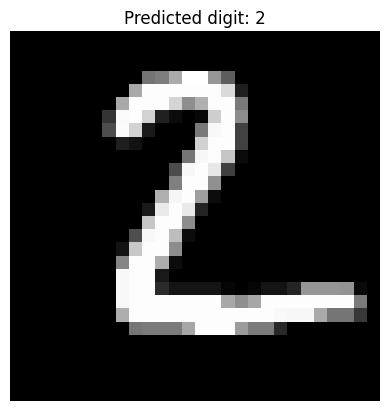

In [ ]:
# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test accuracy:", test_acc)

# Make predictions
predictions = model.predict(test_images)

# Get the predicted digit for the first test image
predicted_digit = np.argmax(predictions[1])
print("Predicted digit:", predicted_digit)

# Display the image of the predicted digit
plt.imshow(test_images[1].reshape(28, 28), cmap='gray')
plt.title(f"Predicted digit: {predicted_digit}")
plt.axis('off')
plt.show()